DATA UNDERSTANDING & CLEANING

In [2]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load Dataset
df = pd.read_csv("SaaS-Sales.csv")
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


In [4]:
#Cek Ukuran Dataset
df.shape

(9994, 19)

Dataset ini terdiri dari 9.994 baris dan 19 kolom. Setiap baris merepresentasikan satu transaksi penjualan produk SaaS kepada customer.

In [5]:
#Cek Nama Kolom
pd.DataFrame(df.columns, columns=['Column Name'])

,Column Name
0,Row ID
1,Order ID
2,Order Date
3,Date Key
4,Contact Name
5,Country
6,City
7,Region
8,Subregion
9,Customer


Dataset ini berisi data transaksi penjualan produk SaaS B2B. Kolom-kolom di dalam dataset mencakup informasi order, customer, lokasi, industri, segment, produk, nilai penjualan, quantity, discount, dan profit.

In [6]:
#Cek Informasi Tipe Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

Berdasarkan informasi tipe data, sebagian besar kolom kategorikal terbaca sebagai object, sedangkan kolom numerik seperti Sales, Quantity, Discount, dan Profit sudah terbaca sebagai tipe numerik. Kolom Order Date masih terbaca sebagai object, sehingga pada tahap data cleaning perlu diubah menjadi format datetime agar dapat digunakan untuk analisis tren waktu.

int64: angka bulat/integer
float64: angka desimal
object: teks/string
datetime: tanggal

In [7]:
#Data Cleaning - Ubah Order Date yang object menjadi datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
#cek Periode
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2020-01-04 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [9]:
#Cek Statistik Deskriptif Numerik
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


Statistik deskriptif digunakan untuk memahami sebaran awal data numerik seperti Sales, Quantity, Discount, dan Profit. Dari tahap ini, dapat dilihat nilai rata-rata, median, minimum, maksimum, serta indikasi awal adanya outlier pada kolom Sales dan Profit.

1. count: 9994 = tidak ada missing value di kolom numerik
2. Mean Sales: 229.858, Median Sales: 54.49
Sebagian besar transaksi sales-nya kecil, tapi ada beberapa transaksi dengan nilai sales sangat besar yang membuat rata-rata naik
3. Quantity: Kebanyakan order jumlahnya kecil 2-5 unit
4. Discount: Rata" 15%, median 20%. Mayoritas diskonnya 20% tapi ada yang 80%.
5. Profit: Min minus artinya ada transaksi yang menghasilkan kerugian besar. Mean besar sedangkan median kecil, artinya ada beberapa transaksi dengan profit sangat tinggi yang menaikkan rata-rata.

Kolom kemungkinan banyak outliers Sales, Profit, Discount karena nilai maksimum dan minimum sangat jauh dari median.

In [10]:
#Data Cleaning - Cek Outlier

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return {
        'column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percentage': len(outliers) / len(data) * 100
    }

outlier_sales = detect_outliers_iqr(df, 'Sales')
outlier_profit = detect_outliers_iqr(df, 'Profit')
outlier_discount = detect_outliers_iqr(df, 'Discount')

pd.DataFrame([outlier_sales, outlier_profit, outlier_discount])

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,Sales,17.28000,209.940,192.66000,-271.710000,498.930000,1167,11.677006
1,Profit,1.72875,29.364,27.63525,-39.724125,70.816875,1881,18.821293
2,Discount,0.00000,0.200,0.20000,-0.300000,0.500000,856,8.565139


In [11]:
#Cek Statistik Kolom Kategorikal
df.describe(include='object')

,Order ID,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,37,2001,922,4219,2507,192,2127,5191,1842,1


Statistik deskriptif untuk kolom kategorikal digunakan untuk melihat jumlah kategori unik dan nilai yang paling sering muncul pada kolom seperti Country, Region, Customer, Industry, Segment, dan Product.

1. Order ID: Tidak semuanya unik
2. Country: Negara yang paling sering muncul adalah United States sebanyak 2,001 transaksi
3. City: Kota yang paling sering muncul adalah London sebanyak 922 transaksi
4. Region: Region yang paling dominan adalah EMEA sebanyak 4,219 transaksi
5. Sub region: Subregion yang paling sering muncul adalah NAMER sebanyak 2,507 transaksi
6. Customer: Customer yang paling sering muncul adalah Allianz sebanyak 192 transaksi
7. Industry: Industri yang paling banyak muncul adalah Finance sebanyak 2,127 transaksi
8. Segment: Segment paling dominan adalah SMB sebanyak 5,191 transaksi

In [12]:
#Cek Jumlah Unique Value per Kolom
df.nunique().sort_values(ascending=False)

Row ID          9994
License         9994
Profit          7287
Sales           5825
Order ID        5009
Date Key        1237
Order Date      1237
Contact Name     793
City             262
Customer ID       99
Customer          99
Country           48
Product           14
Quantity          14
Subregion         12
Discount          12
Industry          10
Region             3
Segment            3
dtype: int64

In [13]:
#Cek Missing Value
df.isna().sum()

Row ID          0
Order ID        0
Order Date      0
Date Key        0
Contact Name    0
Country         0
City            0
Region          0
Subregion       0
Customer        0
Customer ID     0
Industry        0
Segment         0
Product         0
License         0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [14]:
#Cek Duplicate Awal
df.duplicated().sum()

np.int64(0)

Tidak ditemukan duplicate row pada dataset, sehingga tidak ada transaksi yang terduplikasi secara penuh.

In [15]:
#Cek Distribusi Kategori Utama - Region
df['Region'].value_counts()

Region
EMEA    4219
AMER    3665
APJ     2110
Name: count, dtype: int64

In [16]:
#Cek Distribusi Kategori Utama - Segment
df['Segment'].value_counts()

Segment
SMB           5191
Strategic     3020
Enterprise    1783
Name: count, dtype: int64

In [17]:
#Cek Distribusi Kategori Utama - Industry
df['Industry'].value_counts()

Industry
Finance              2127
Energy               1316
Tech                 1236
Manufacturing        1222
Healthcare           1049
Consumer Products    1021
Retail                972
Communications        593
Transportation        351
Misc                  107
Name: count, dtype: int64

In [18]:
#Cek Distribusi Kategori Utama - Product
df['Product'].value_counts()

Product
ContactMatcher                1842
Support                       1560
FinanceHub                     981
SaaS Connector Pack            957
Site Analytics                 889
Marketing Suite - Gold         846
ChatBot Plugin                 796
Data Smasher                   775
OneView                        466
SaaS Connector Pack - Gold     254
Marketing Suite                228
Storage                        217
Big Ol Database                115
Alchemy                         68
Name: count, dtype: int64

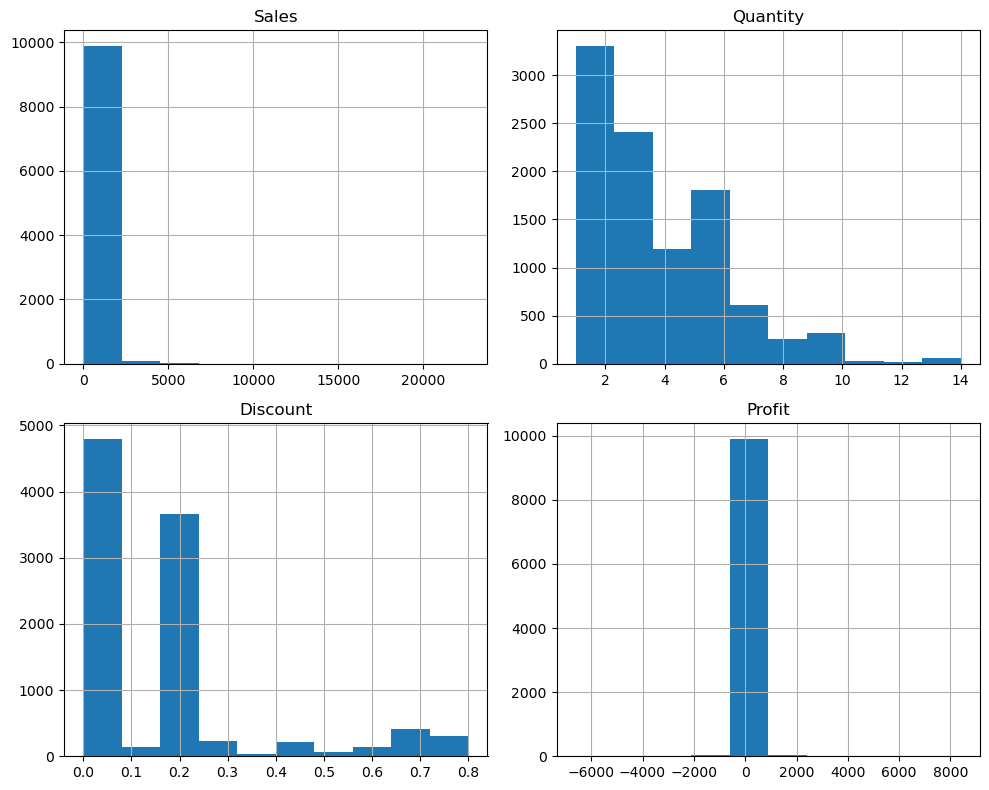

In [19]:
#Cek Data Numerik dengan Histogram
df[['Sales', 'Quantity', 'Discount', 'Profit']].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

Histogram digunakan untuk melihat bentuk distribusi awal pada kolom numerik. 

Sales dan Profit terlihat tidak berdistribusi normal dan cenderung memiliki skewness karena adanya beberapa transaksi dengan nilai yang jauh lebih besar dibanding transaksi lainnya.

1. Distribusi Sales menunjukkan bahwa sebagian besar transaksi berada pada nilai sales yang rendah. Namun, terdapat beberapa transaksi dengan nilai sales sangat tinggi, sehingga data Sales cenderung right-skewed dan memiliki kemungkinan outliers.
2. Distribusi Quantity menunjukkan bahwa sebagian besar transaksi memiliki jumlah pembelian yang kecil, terutama antara 1 sampai 6 unit. Quantity yang lebih tinggi jarang muncul dalam dataset.
3. Distribusi Discount menunjukkan bahwa sebagian besar transaksi memiliki discount antara 0% sampai 20%. Namun, terdapat beberapa transaksi dengan discount tinggi hingga 80%, sehingga perlu dianalisis apakah discount tinggi berpengaruh terhadap profit.
4. Distribusi Profit menunjukkan bahwa sebagian besar transaksi berada di sekitar nilai profit kecil. Namun, terdapat nilai profit ekstrem, baik negatif maupun positif. Hal ini menunjukkan adanya kemungkinan outliers pada kolom Profit.

Berdasarkan histogram, semua kolom numerik memiliki pola distribusi yang tidak sepenuhnya normal. Sales dan Profit menunjukkan outliers yang paling ekstrem karena memiliki rentang nilai yang sangat besar. Namun, Quantity dan Discount juga tetap perlu dicek outliers-nya, karena terdapat nilai Quantity yang lebih tinggi dari mayoritas transaksi dan Discount yang mencapai 80%. Oleh karena itu, pengecekan outliers sebaiknya dilakukan pada semua kolom numerik, yaitu Sales, Quantity, Discount, dan Profit.

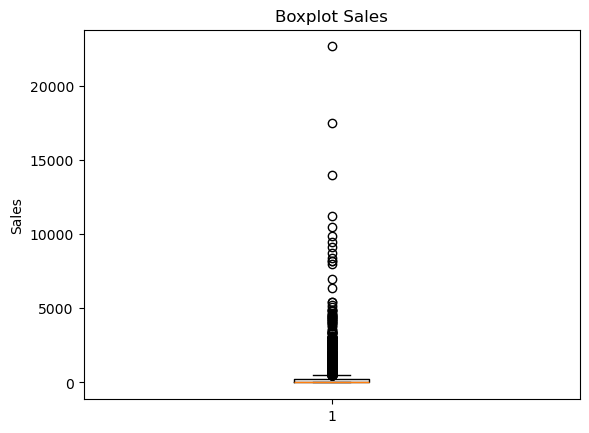

In [20]:
#Cek Outlier Awal dengan Boxplot - Sales

plt.boxplot(df['Sales'])
plt.title('Boxplot Sales')
plt.ylabel('Sales')
plt.show()

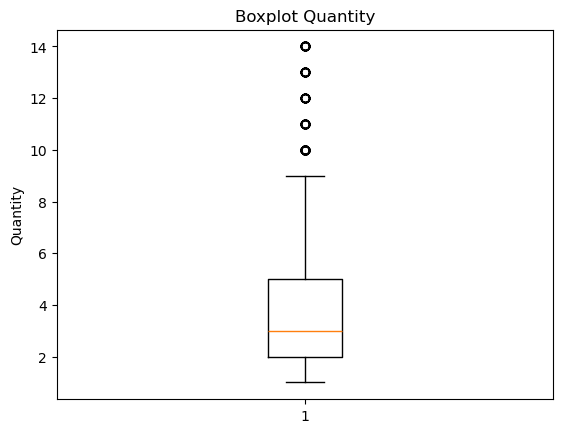

In [22]:
#Cek Outlier Awal dengan Boxplot - Quantity

plt.boxplot(df['Quantity'])
plt.title('Boxplot Quantity')
plt.ylabel('Quantity')
plt.show()

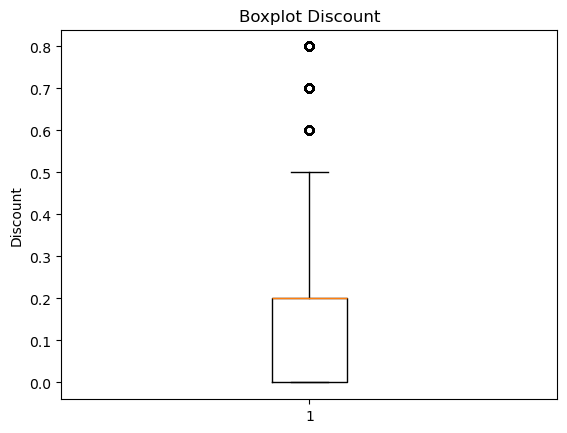

In [23]:
#Cek Outlier Awal dengan Boxplot - Discount

plt.boxplot(df['Discount'])
plt.title('Boxplot Discount')
plt.ylabel('Discount')
plt.show()

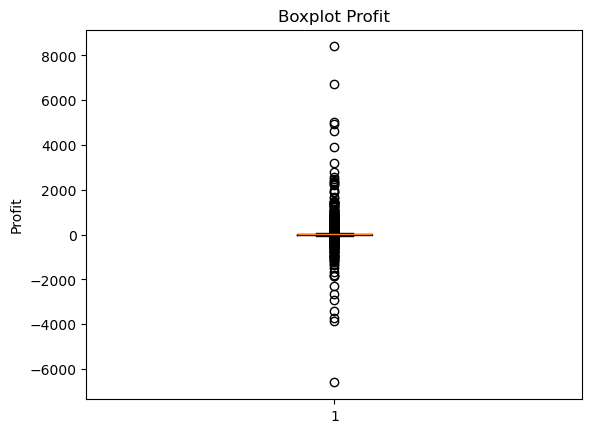

In [25]:
#Cek Outlier Awal dengan Boxplot - Profit

plt.boxplot(df['Profit'])
plt.title('Boxplot Profit')
plt.ylabel('Profit')
plt.show()

In [26]:
#Data Cleaning - Buat Kolom Baru (Year, Month, Month-Year)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Month-Year'] = df['Order Date'].dt.to_period('M').astype(str)

In [27]:
#Data Cleaning - Buat Kolom Baru (Profit Margin)
df['Profit Margin'] = np.where(
    df['Sales'] != 0,
    df['Profit'] / df['Sales'],
    0
)

In [28]:
#Data Cleaning - Buat Kolom Baru (Profil Status)
df['Profit Status'] = np.where(df['Profit'] >= 0, 'Profit', 'Loss')

In [29]:
#Data Cleaning - Buat Kolom Baru (Discount Group)

df['Discount Group'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.5, 1],
    labels=['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']
)

In [30]:
#Data Cleaning - Buat Kolom Baru (Sales Level)
df['Sales Level'] = pd.qcut(
    df['Sales'],
    q=4,
    labels=['Low Sales', 'Medium Low Sales', 'Medium High Sales', 'High Sales']
)

In [31]:
#Cek hasil akhir Data Cleaning
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,...,Discount,Profit,Year,Month,Month Name,Month-Year,Profit Margin,Profit Status,Discount Group,Sales Level
0,1,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,0.00,41.9136,2022,11,November,2022-11,0.1600,Profit,No Discount,High Sales
1,2,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,0.00,219.5820,2022,11,November,2022-11,0.3000,Profit,No Discount,High Sales
2,3,AMER-2022-138688,2022-06-13,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,...,0.00,6.8714,2022,6,June,2022-06,0.4700,Profit,No Discount,Low Sales
3,4,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,0.45,-383.0310,2021,10,October,2021-10,-0.4000,Loss,Medium Discount,High Sales
4,5,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,0.20,2.5164,2021,10,October,2021-10,0.1125,Profit,Low Discount,Medium Low Sales


In [32]:
#Cek hasil akhir Data Cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Date Key        9994 non-null   int64         
 4   Contact Name    9994 non-null   object        
 5   Country         9994 non-null   object        
 6   City            9994 non-null   object        
 7   Region          9994 non-null   object        
 8   Subregion       9994 non-null   object        
 9   Customer        9994 non-null   object        
 10  Customer ID     9994 non-null   int64         
 11  Industry        9994 non-null   object        
 12  Segment         9994 non-null   object        
 13  Product         9994 non-null   object        
 14  License         9994 non-null   object        
 15  Sale

In [33]:
#Cek hasil akhir Data Cleaning
df.shape

(9994, 27)

STATISTICAL DATA ANALYSIS

In [34]:
df[['Profit Margin', 'Profit Status', 'Discount Group', 'Sales Level']].head()

,Profit Margin,Profit Status,Discount Group,Sales Level
0,0.1600,Profit,No Discount,High Sales
1,0.3000,Profit,No Discount,High Sales
2,0.4700,Profit,No Discount,Low Sales
3,-0.4000,Loss,Medium Discount,High Sales
4,0.1125,Profit,Low Discount,Medium Low Sales


In [35]:
df['Profit Status'].value_counts()

Profit Status
Profit    8123
Loss      1871
Name: count, dtype: int64

In [36]:
df['Discount Group'].value_counts()

Discount Group
No Discount        4798
Low Discount       3803
High Discount       856
Medium Discount     537
Name: count, dtype: int64

In [37]:
df['Sales Level'].value_counts()

Sales Level
Low Sales            2501
Medium High Sales    2499
High Sales           2498
Medium Low Sales     2496
Name: count, dtype: int64

In [38]:
#Summary KPI Utama

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
total_products = df['Product'].nunique()

summary_kpi = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Profit Margin',
        'Total Orders',
        'Total Customers',
        'Total Products'
    ],
    'Value': [
        total_sales,
        total_profit,
        profit_margin,
        total_orders,
        total_customers,
        total_products
    ]
})

summary_kpi

summary_kpi_formatted = summary_kpi.copy()

summary_kpi_formatted['Value'] = [
    f"{total_sales:,.2f}",
    f"{total_profit:,.2f}",
    f"{profit_margin:.2%}",
    f"{total_orders:,.0f}",
    f"{total_customers:,.0f}",
    f"{total_products:,.0f}"
]

summary_kpi_formatted

,Metric,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Profit Margin,12.47%
3,Total Orders,"5,009"
4,Total Customers,99
5,Total Products,14


Summary KPI digunakan untuk melihat performa bisnis secara keseluruhan sebelum masuk ke analisis yang lebih detail. Metrik utama yang dilihat adalah total sales, total profit, profit margin, jumlah order, jumlah customer, dan jumlah product.

Insight 1: Overall Business Performance

Berdasarkan summary KPI, perusahaan SaaS mencatat total sales sebesar sekitar 2.3 juta dengan total profit sekitar 286 ribu. Profit margin keseluruhan perusahaan adalah sekitar 12.47%, yang menunjukkan bahwa dari setiap 100 nilai sales, perusahaan menghasilkan sekitar 12.47 sebagai profit. Dataset ini mencakup 5,009 order, 99 customer, dan 14 produk.

In [39]:
#Statistik Deskriptif - Kolom Numerik
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin']].describe()

,Sales,Quantity,Discount,Profit,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,0.120314
std,623.245101,2.225110,0.206452,234.260108,0.466754
min,0.444000,1.000000,0.000000,-6599.978000,-2.750000
25%,17.280000,2.000000,0.000000,1.728750,0.075000
50%,54.490000,3.000000,0.200000,8.666500,0.270000
75%,209.940000,5.000000,0.200000,29.364000,0.362500
max,22638.480000,14.000000,0.800000,8399.976000,0.500000


Perbedaan antara mean dan median menunjukkan bahwa data memiliki distribusi yang tidak simetris, terutama pada Sales dan Profit. Hal ini umum terjadi pada data transaksi karena sebagian besar transaksi bernilai kecil atau sedang, sementara beberapa transaksi memiliki nilai yang sangat besar.

1. Count 9994 = Seluruh kolom numerik memiliki 9.994 data, sehingga tidak terdapat missing value pada kolom Sales, Quantity, Discount, Profit, dan Profit Margin.
2. Sales = Rata-rata Sales 229.86, tetapi median (50%) hanya 54.5
Sebagian besar transaksi memiliki nilai sales rendah, tetapi terdapat beberapa transaksi dengan nilai sales sangat tinggi yang membuat rata-rata meningkat.
3. Quantity = Median sebesar 3, dengan mayoritas transaksi berada pada rentang 2 sampai 5 unit = sebagian besar pembelian dilakukan dalam jumlah kecil.
4. Discount = Sebagian besar transaksi mendapat discount maksimal 20%, walaupun ada discount sampai 80%.
5. Profit: Rata-rata 28.66 dan median 8.67. Nilai minimum profit mencapai -6,599.98, sedangkan nilai maksimum mencapai 8,399.98 = adanya transaksi dengan kerugian besar dan keuntungan besar.
6. Profit Margin (Profit/Sales) = Secara umum transaksi masih menghasilkan margin positif, tapi ada beberapa transaksi yang rugi sangat besar dibandingkan nilai sales-nya.

In [40]:
#Uji Normalitas
from scipy.stats import shapiro

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

normality_results = []

for col in numeric_cols:
    sample_data = df[col].sample(500, random_state=42)
    stat, p_value = shapiro(sample_data)
    normality_results.append([col, stat, p_value])

normality_df = pd.DataFrame(
    normality_results,
    columns=['Column', 'Statistic', 'p-value']
)

normality_df

,Column,Statistic,p-value
0,Sales,0.443834,1.432315e-36
1,Quantity,0.896800,7.516270e-18
2,Discount,0.697789,5.626127e-29
3,Profit,0.431111,7.187819e-37


Uji normalitas dilakukan untuk mengetahui apakah data numerik berdistribusi normal. Hipotesis yang digunakan adalah:

H0: Data berdistribusi normal.
H1: Data tidak berdistribusi normal.

Jika p-value < 0.05, maka H0 ditolak, sehingga data tidak berdistribusi normal.

In [41]:
#Uji Korelasi Spearman - Data tidak normal

corr_spearman = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin']].corr(method='spearman')
corr_spearman

,Sales,Quantity,Discount,Profit,Profit Margin
Sales,1.000000,0.327426,-0.056969,0.518407,-0.199872
Quantity,0.327426,1.000000,-0.000878,0.234491,0.000877
Discount,-0.056969,-0.000878,1.000000,-0.543350,-0.645112
Profit,0.518407,0.234491,-0.543350,1.000000,0.500253
Profit Margin,-0.199872,0.000877,-0.645112,0.500253,1.000000


Nilai korelasi	Artinya
Mendekati 1: hubungan positif kuat
Mendekati -1: hubungan negatif kuat
Mendekati 0: hampir tidak ada hubungan
Positif: kalau satu naik, yang lain cenderung ikut naik
Negatif: kalau satu naik, yang lain cenderung turun

1. Sales dan Profit: hubungan positif sedang.
Sales memiliki korelasi positif sedang dengan Profit sebesar 0.518. Hal ini menunjukkan bahwa semakin tinggi nilai sales, profit cenderung ikut meningkat, meskipun hubungan tersebut tidak terlalu kuat.
2. Discount dan Profit: hubungan negatif sedang.
Discount memiliki korelasi negatif sedang dengan Profit sebesar -0.543. Hal ini menunjukkan bahwa semakin tinggi discount yang diberikan, profit cenderung menurun.
3. Discount dan Profit Margin: hubungan negatif cukup kuat.
Discount memiliki korelasi negatif cukup kuat dengan Profit Margin sebesar -0.645. Hal ini menunjukkan bahwa discount yang tinggi dapat menurunkan profit margin.
4. Profit dan Profit Margin: hubungan positif sedang
Profit memiliki korelasi positif sedang dengan Profit Margin sebesar 0.500. Hal ini menunjukkan bahwa transaksi dengan profit lebih tinggi cenderung memiliki margin keuntungan yang lebih baik.
5. Quantity dan Sales: hubungan positif lemah sampai sedang
Quantity memiliki korelasi positif lemah hingga sedang dengan Sales sebesar 0.327. Artinya, semakin banyak quantity yang dibeli, sales cenderung meningkat, tetapi tidak terlalu kuat karena sales juga dipengaruhi oleh harga produk.
6. Quantity dan Discount hampir tidak berhubungan
Quantity hampir tidak memiliki hubungan dengan Discount karena nilai korelasinya mendekati 0.

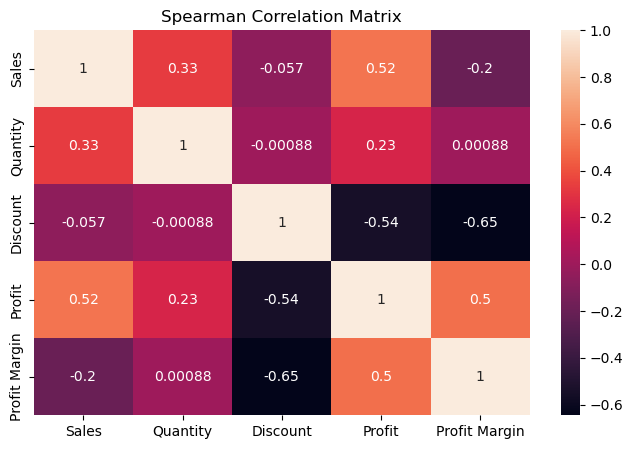

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(corr_spearman, annot=True)
plt.title('Spearman Correlation Matrix')
plt.show()

In [45]:
#Uji beda profit transaksi diskon vs non-diskon

from scipy.stats import mannwhitneyu

profit_discount = df[df['Discount'] > 0]['Profit']
profit_no_discount = df[df['Discount'] == 0]['Profit']

stat, p_value = mannwhitneyu(
    profit_discount,
    profit_no_discount,
    alternative='two-sided'
)

print('Statistic:', stat)
print('p-value:', p_value)

Statistic: 6266805.5
p-value: 0.0


Uji Mann-Whitney U digunakan untuk mengetahui apakah terdapat perbedaan profit yang signifikan antara transaksi dengan diskon dan transaksi tanpa diskon.

H0: Tidak terdapat perbedaan profit yang signifikan antara transaksi dengan diskon dan tanpa diskon.

H1: Terdapat perbedaan profit yang signifikan antara transaksi dengan diskon dan tanpa diskon.

p-value < 0.05, maka H0 ditolak.

Note: Uji ini hanya menjelaskan bahwa iya ada perbedaan antara kelompok profit dengan diskon dan tanpa diskon. Tapi tidak menjelaskan perbedaannya apa (lebih untung/rugi)

In [43]:
#Melihat Perbedaan Kelompok Transaksi dengan Diskon dan Tanpa Diskon

discount_summary = df.groupby(df['Discount'] > 0).agg(
    Transaction_Count=('Profit', 'count'),
    Average_Profit=('Profit', 'mean'),
    Median_Profit=('Profit', 'median'),
    Total_Profit=('Profit', 'sum'),
    Average_Discount=('Discount', 'mean')
).reset_index()

discount_summary['Discount Status'] = discount_summary['Discount'].map({
    True: 'With Discount',
    False: 'No Discount'
})

discount_summary = discount_summary[[
    'Discount Status',
    'Transaction_Count',
    'Average_Profit',
    'Median_Profit',
    'Total_Profit',
    'Average_Discount'
]]

discount_summary

,Discount Status,Transaction_Count,Average_Profit,Median_Profit,Total_Profit,Average_Discount
0,No Discount,4798,66.900292,15.9952,320987.6032,0.000000
1,With Discount,5196,-6.657156,3.3408,-34590.5815,0.300441


Business Insight

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)

In [45]:
#Insight 1 — Overall Business Performance

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
total_products = df['Product'].nunique()

summary_kpi = pd.DataFrame({
    'Metric': ['Total Sales', 'Total Profit', 'Profit Margin', 'Total Orders', 'Total Customers', 'Total Products'],
    'Value': [total_sales, total_profit, profit_margin, total_orders, total_customers, total_products]
})

summary_kpi

,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Profit Margin,1.246722e-01
3,Total Orders,5.009000e+03
4,Total Customers,9.900000e+01
5,Total Products,1.400000e+01


In [48]:
summary_kpi_formatted = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Profit Margin',
        'Total Orders',
        'Total Customers',
        'Total Products'
    ],
    'Value': [
        f"{total_sales:,.2f}",
        f"{total_profit:,.2f}",
        f"{profit_margin:.2%}",
        f"{total_orders:,.0f}",
        f"{total_customers:,.0f}",
        f"{total_products:,.0f}"
    ]
})

summary_kpi_formatted

,Metric,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Profit Margin,12.47%
3,Total Orders,"5,009"
4,Total Customers,99
5,Total Products,14


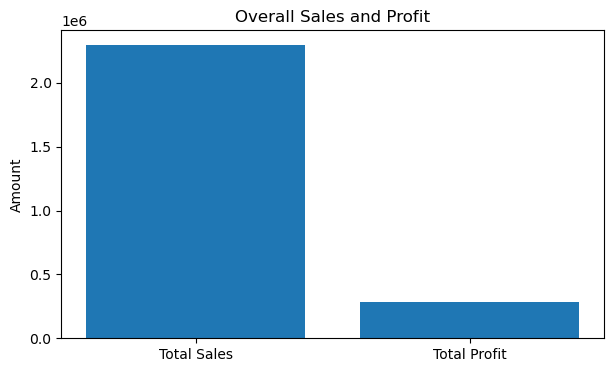

In [49]:
kpi_plot = summary_kpi.copy()
kpi_plot = kpi_plot[kpi_plot['Metric'].isin(['Total Sales', 'Total Profit'])]

plt.figure(figsize=(7,4))
plt.bar(kpi_plot['Metric'], kpi_plot['Value'])
plt.title('Overall Sales and Profit')
plt.ylabel('Amount')
plt.show()

Berdasarkan summary KPI, perusahaan mencatat total sales sekitar 2.3 juta dengan total profit sekitar 286 ribu. Profit margin keseluruhan berada di sekitar 12.47%, yang berarti dari setiap 100 nilai sales, perusahaan menghasilkan sekitar 12.47 sebagai profit.

Visualisasi Sales vs Profit menunjukkan bahwa selisih antara sales dan profit cukup besar. Hal ini menunjukkan bahwa sales yang tinggi belum tentu menghasilkan profit yang sebanding. Oleh karena itu, analisis selanjutnya perlu melihat faktor-faktor yang memengaruhi profitabilitas, seperti region, product, industry, segment, dan discount.

In [50]:
#Insight 2 — Profit vs Loss Transactions
#Untuk melihat proporsi transaksi yang menghasilkan keuntungan dan transaksi yang mengalami kerugian.
profit_status_summary = df.groupby('Profit Status').agg(
    Transaction_Count=('Order ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

profit_status_summary['Transaction %'] = (
    profit_status_summary['Transaction_Count'] / len(df) * 100
)

profit_status_summary

,Profit Status,Transaction_Count,Total_Sales,Total_Profit,Transaction %
0,Loss,1871,4.687072e+05,-156131.2857,18.721233
1,Profit,8123,1.828494e+06,442528.3074,81.278767


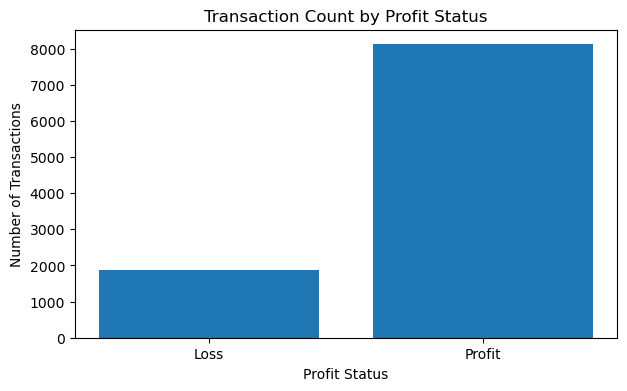

In [51]:
plt.figure(figsize=(7,4))
plt.bar(profit_status_summary['Profit Status'], profit_status_summary['Transaction_Count'])
plt.title('Transaction Count by Profit Status')
plt.xlabel('Profit Status')
plt.ylabel('Number of Transactions')
plt.show()

Berdasarkan analisis profit status, transaksi dibagi menjadi dua kelompok, yaitu transaksi yang menghasilkan profit dan transaksi yang mengalami loss. Transaksi loss tetap menghasilkan sales, tetapi memberikan kontribusi negatif terhadap profit perusahaan.

Hal ini menunjukkan bahwa perusahaan tidak cukup hanya mengejar peningkatan sales, tetapi juga perlu mengevaluasi transaksi yang menghasilkan loss. Analisis lanjutan perlu dilakukan untuk mengetahui apakah transaksi loss lebih banyak terjadi pada product, region, segment, atau tingkat discount tertentu.

Chart ini menunjukkan bahwa perusahaan secara umum masih memiliki performa transaksi yang positif karena sebagian besar transaksi menghasilkan profit. Namun, keberadaan transaksi loss menunjukkan adanya area bisnis yang belum optimal. Transaksi loss perlu dianalisis lebih lanjut karena dapat menjadi indikasi masalah pada strategi discount, pricing, product mix, atau cost structure.

In [54]:
#Insight 3 — Monthly Sales and Profit Trend
#Apakah sales dan profit bergerak searah dari waktu ke waktu?

monthly_trend = df.groupby('Month-Year').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

monthly_trend

,Month-Year,Sales,Profit
0,2020-01,13946.2290,2446.7711
1,2020-02,4810.5580,865.7280
2,2020-03,55691.0090,498.7299
3,2020-04,28295.3450,3488.8352
4,2020-05,23648.2870,2738.7096
5,2020-06,34595.1276,4976.5244
6,2020-07,33946.3930,-841.4826
7,2020-08,27909.4685,5318.1050
8,2020-09,81777.3508,8328.0994
9,2020-10,31453.3930,3448.2573


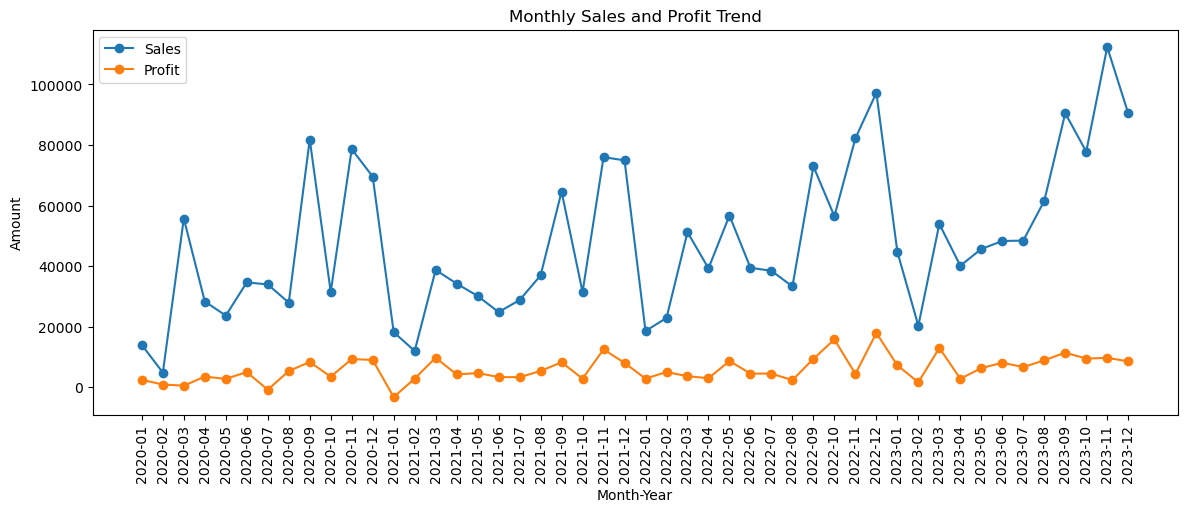

In [55]:
plt.figure(figsize=(14,5))
plt.plot(monthly_trend['Month-Year'], monthly_trend['Sales'], marker='o', label='Sales')
plt.plot(monthly_trend['Month-Year'], monthly_trend['Profit'], marker='o', label='Profit')

plt.title('Monthly Sales and Profit Trend')
plt.xlabel('Month-Year')
plt.ylabel('Amount')
plt.xticks(rotation=90)
plt.legend()
plt.show()

Berdasarkan chart Monthly Sales and Profit Trend, sales dan profit mengalami perubahan dari waktu ke waktu. Analisis ini digunakan untuk melihat apakah peningkatan sales selalu diikuti oleh peningkatan profit.

Jika terdapat periode dengan sales tinggi tetapi profit tidak meningkat sejalan, hal tersebut menunjukkan bahwa sales yang tinggi belum tentu menghasilkan profit yang optimal. Kondisi ini dapat dipengaruhi oleh faktor seperti discount, product mix, region, atau transaksi loss pada periode tersebut.

Berdasarkan chart Monthly Sales and Profit Trend, sales dan profit mengalami fluktuasi dari bulan ke bulan. Sales terlihat cenderung meningkat terutama pada tahun 2023, dengan beberapa bulan mencatat nilai sales yang tinggi. Namun, peningkatan sales tidak selalu diikuti oleh peningkatan profit yang sebanding.

Hal ini menunjukkan bahwa sales yang tinggi belum tentu menghasilkan profit yang optimal. Perbedaan pergerakan antara sales dan profit dapat dipengaruhi oleh beberapa faktor seperti tingkat discount, product mix, region, atau transaksi dengan profit margin rendah. Oleh karena itu, analisis profitabilitas perlu dilakukan lebih lanjut, tidak hanya berdasarkan total sales.

Intinya: Sales meningkat dan fluktuatif, tetapi profit tidak selalu naik sebanding. Artinya, perusahaan perlu fokus pada profitable sales, bukan hanya mengejar revenue.

In [56]:
#Insight 4 — Region Performance
#Region mana yang paling menghasilkan sales, profit, dan profit margin?

region_perf = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

region_perf['Profit Margin'] = region_perf['Profit'] / region_perf['Sales']

region_perf.sort_values('Profit Margin', ascending=False)

,Region,Sales,Profit,Orders,Profit Margin
0,AMER,8.378496e+05,127426.9898,1842,0.152088
2,EMEA,1.043887e+06,147456.0450,2098,0.141257
1,APJ,4.154642e+05,11513.9869,1069,0.027714


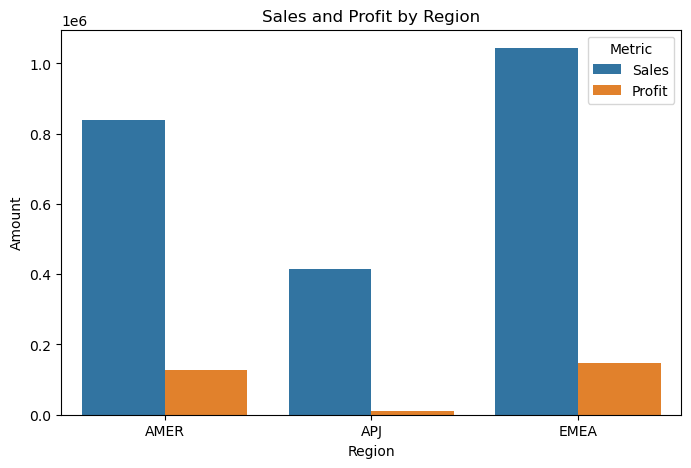

In [57]:
#Visualisasi Sales vs Profit by Region
region_melt = region_perf.melt(
    id_vars='Region',
    value_vars=['Sales', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(8,5))
sns.barplot(data=region_melt, x='Region', y='Amount', hue='Metric')
plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.show()

EMEA adalah region dengan kontribusi revenue terbesar, tetapi AMER juga cukup kuat karena profit-nya tidak jauh tertinggal dibanding EMEA.

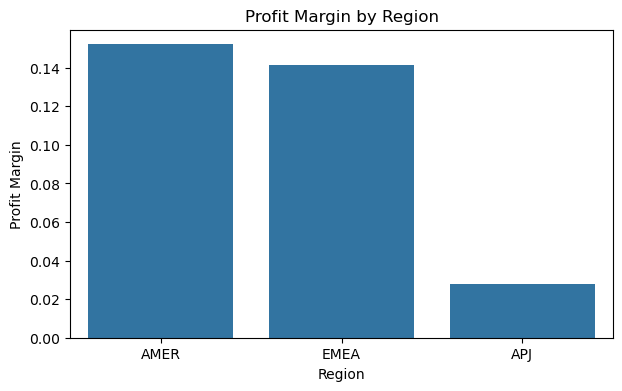

In [58]:
#Visualisasi Sales vs Profit by Region

plt.figure(figsize=(7,4))
sns.barplot(
    data=region_perf.sort_values('Profit Margin', ascending=False),
    x='Region',
    y='Profit Margin'
)
plt.title('Profit Margin by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin')
plt.show()

Berdasarkan analisis region, performa setiap region perlu dilihat dari tiga sisi, yaitu sales, profit, dan profit margin. Region dengan sales tinggi belum tentu menjadi region yang paling profitable jika profit margin-nya rendah.

Chart Sales and Profit by Region menunjukkan kontribusi sales dan profit dari masing-masing region. Sementara itu, chart Profit Margin by Region menunjukkan efisiensi profitabilitas tiap region. Analisis ini penting untuk menentukan region mana yang perlu diprioritaskan dan region mana yang perlu dievaluasi dari sisi pricing, discount, atau product mix.

Berdasarkan analisis region, EMEA memiliki total sales tertinggi, diikuti oleh AMER, sedangkan APJ memiliki sales paling rendah. Dari sisi profit margin, AMER memiliki margin tertinggi, disusul EMEA, sementara APJ memiliki profit margin paling rendah.

Hal ini menunjukkan bahwa performa region tidak cukup hanya dilihat dari total sales. EMEA unggul dari sisi revenue, tetapi AMER memiliki profitabilitas yang sedikit lebih baik. Sementara itu, APJ perlu menjadi perhatian karena memiliki sales dan profit margin paling rendah. Region APJ perlu dievaluasi lebih lanjut dari sisi product mix, discount strategy, pricing, atau customer segment untuk meningkatkan profitabilitas.

EMEA menjadi region dengan sales tertinggi, namun AMER memiliki profit margin terbaik. APJ menjadi region yang perlu dievaluasi karena memiliki sales dan profit margin paling rendah.

Actionable reccomendation: Perusahaan dapat memprioritaskan EMEA dan AMER sebagai region utama untuk mempertahankan pertumbuhan sales dan profit. Untuk APJ, perusahaan perlu melakukan evaluasi terhadap produk yang dijual, tingkat discount, segment customer, dan pricing strategy karena region ini memiliki profit margin yang jauh lebih rendah dibanding region lain.

In [59]:
#Insight 5 — Subregion Performance
#Melihat subregion mana yang paling besar kontribusinya terhadap profit, dan subregion mana yang perlu dievaluasi.

subregion_perf = df.groupby('Subregion').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

subregion_perf['Profit Margin'] = subregion_perf['Profit'] / subregion_perf['Sales']

subregion_perf.sort_values('Profit', ascending=False)


,Subregion,Sales,Profit,Orders,Profit Margin
9,NAMER,596328.9015,109784.0388,1277,0.184100
11,UKIR,347468.0210,85238.2452,623,0.245312
1,APAC,106771.2120,30311.1778,211,0.283889
4,EU-WEST,384065.6140,26706.6029,807,0.069537
5,IND,53555.3600,18382.9363,73,0.343251
7,LATAM,241520.7030,17642.9510,565,0.073049
10,NOR,127326.9600,16044.7604,252,0.126012
2,EU,32114.6100,8401.8004,53,0.261619
8,MEA,76793.6960,7200.1468,197,0.093760
3,EU-EAST,76118.1140,3864.4893,166,0.050770


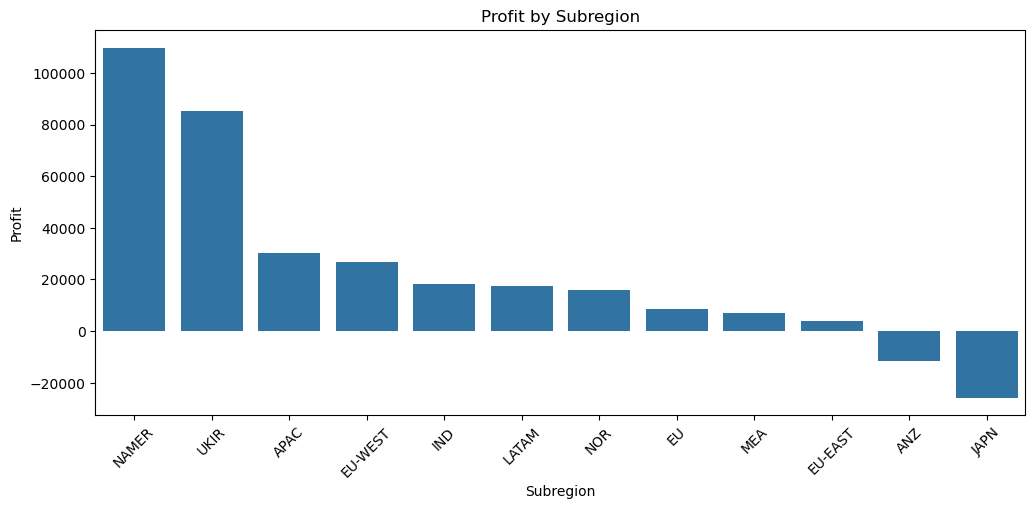

In [60]:
#Visualisasi Profit by Subregion

top_subregion = subregion_perf.sort_values('Profit', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(data=top_subregion, x='Subregion', y='Profit')
plt.title('Profit by Subregion')
plt.xlabel('Subregion')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

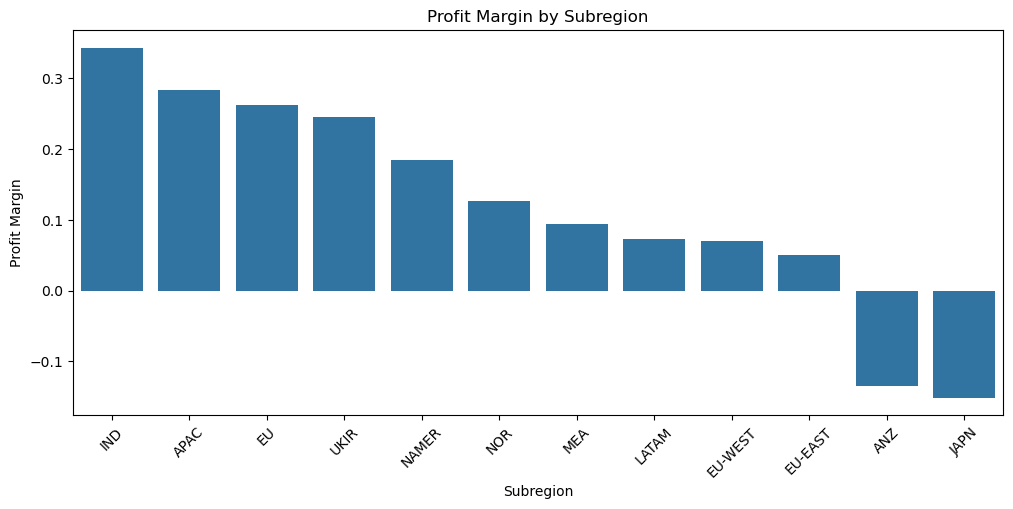

In [61]:
#Visualisasi Profit Margin by Subregion

subregion_margin = subregion_perf.sort_values('Profit Margin', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(data=subregion_margin, x='Subregion', y='Profit Margin')
plt.title('Profit Margin by Subregion')
plt.xlabel('Subregion')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)
plt.show()

Berdasarkan analisis subregion, NAMER menjadi subregion dengan total profit tertinggi, diikuti oleh UKIR, APAC, dan EU-WEST. Hal ini menunjukkan bahwa NAMER dan UKIR merupakan kontributor utama terhadap profit perusahaan.

Namun, dari sisi profit margin, IND memiliki margin tertinggi, disusul APAC, EU, dan UKIR. Ini menunjukkan bahwa subregion dengan total profit terbesar belum tentu memiliki efisiensi profitabilitas terbaik. NAMER memiliki profit total paling besar, tetapi profit margin-nya bukan yang tertinggi.

Selain itu, ANZ dan JAPN memiliki total profit serta profit margin negatif. Kondisi ini menunjukkan bahwa kedua subregion tersebut menjadi area yang perlu dievaluasi lebih lanjut, terutama dari sisi pricing, discount strategy, product mix, atau customer segment.

Actionable Reccomendation:
Perusahaan dapat mempertahankan NAMER dan UKIR sebagai subregion utama karena kontribusi profitnya besar. Di sisi lain, IND dapat dijadikan benchmark karena memiliki profit margin tertinggi. Untuk ANZ dan JAPN, perusahaan perlu melakukan evaluasi lebih detail terhadap strategi diskon, produk yang dijual, dan segment customer karena kedua subregion tersebut menghasilkan profit negatif.

In [62]:
#Insight 6 — Industry Performance
#Mengetahui industry customer mana yang paling besar kontribusinya terhadap sales/profit, dan industry mana yang paling efisien dari sisi profit margin

industry_perf = df.groupby('Industry').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

industry_perf['Profit Margin'] = industry_perf['Profit'] / industry_perf['Sales']

industry_perf.sort_values('Profit', ascending=False)

,Industry,Sales,Profit,Orders,Profit Margin
3,Finance,474150.4844,50348.9696,1074,0.106188
2,Energy,304644.1409,45282.3137,662,0.148640
5,Manufacturing,295192.3812,38413.1064,634,0.130129
1,Consumer Products,224044.1422,37018.0077,476,0.165226
4,Healthcare,273183.2882,31969.0932,515,0.117024
7,Retail,223072.0720,30207.8208,484,0.135417
8,Tech,263169.0277,24615.0436,624,0.093533
0,Communications,120962.2365,13976.3410,296,0.115543
9,Transportation,90191.3276,7402.6967,188,0.082078
6,Misc,28591.7596,7163.6290,56,0.250549


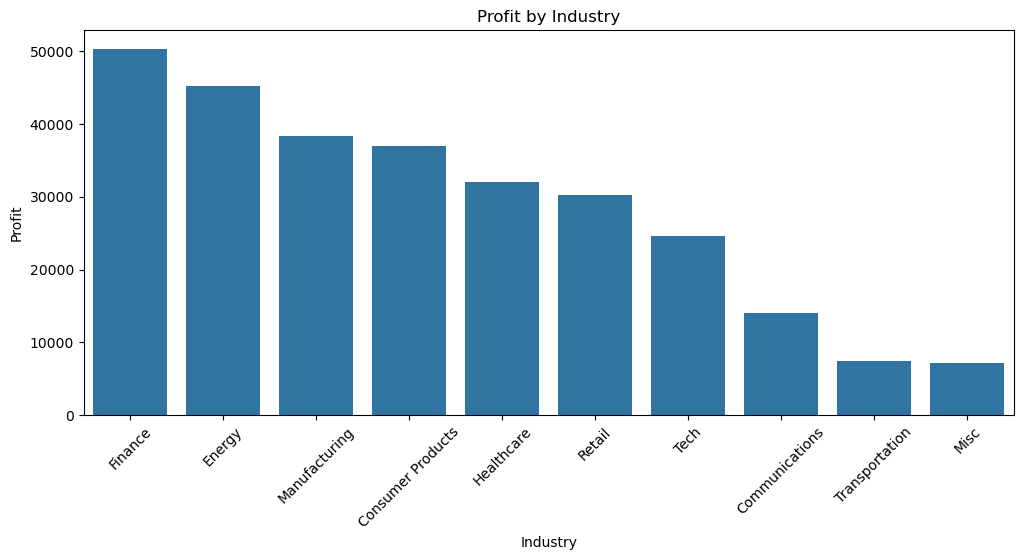

In [68]:
#Visualisasi Profit by Industry

industry_sorted = industry_perf.sort_values('Profit', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(data=industry_sorted, x='Industry', y='Profit')
plt.title('Profit by Industry')
plt.xlabel('Industry')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

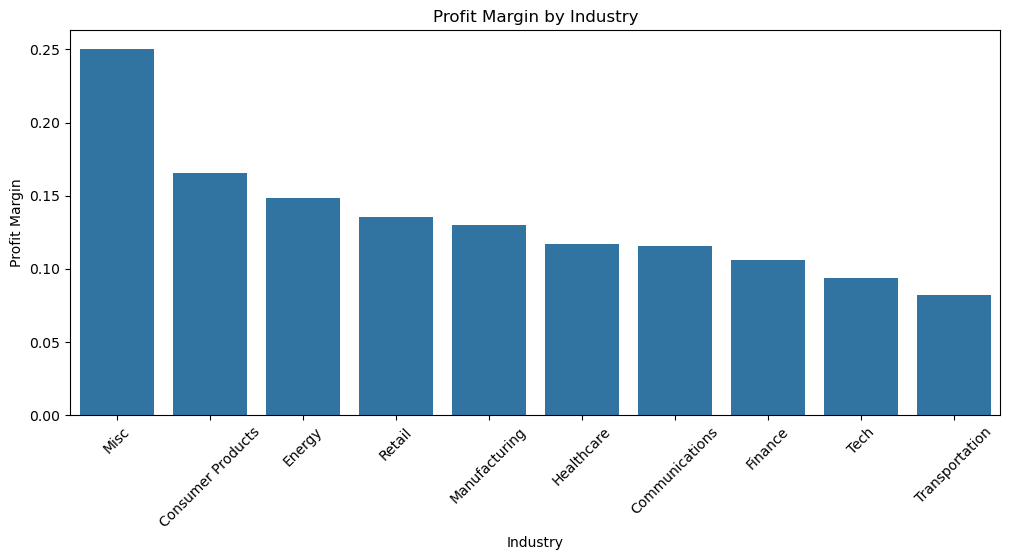

In [69]:
#Visualisasi Profit Margin by Industry

industry_margin = industry_perf.sort_values('Profit Margin', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(data=industry_margin, x='Industry', y='Profit Margin')
plt.title('Profit Margin by Industry')
plt.xlabel('Industry')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)
plt.show()

Berdasarkan analisis industry, Finance merupakan industry dengan total profit tertinggi, diikuti oleh Energy, Manufacturing, dan Consumer Products. Hal ini menunjukkan bahwa Finance menjadi salah satu kontributor utama terhadap profit perusahaan.

Namun, dari sisi profit margin, Misc memiliki margin tertinggi, diikuti oleh Consumer Products dan Energy. Ini menunjukkan bahwa industry dengan total profit terbesar belum tentu memiliki efisiensi profitabilitas terbaik. Finance memiliki total profit tertinggi, tetapi profit margin-nya lebih rendah dibanding beberapa industry lain.

Selain itu, Transportation menjadi industry dengan profit dan profit margin paling rendah, sehingga perlu dievaluasi lebih lanjut dari sisi pricing, discount, product mix, atau customer segment.

Actionable Reccomendation:
Perusahaan dapat memprioritaskan Finance sebagai industry utama karena kontribusi profitnya paling besar. Namun, industry seperti Misc, Consumer Products, dan Energy juga perlu diperhatikan karena memiliki profit margin yang lebih tinggi. Untuk Transportation, perusahaan perlu mengevaluasi strategi penjualan, pricing, discount, atau produk yang ditawarkan karena industry ini memiliki profitabilitas paling rendah.

In [65]:
#Insight 7 — Segment Performance
segment_perf = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

segment_perf['Profit Margin'] = segment_perf['Profit'] / segment_perf['Sales']

segment_perf.sort_values('Profit Margin', ascending=False)

,Segment,Sales,Profit,Orders,Profit Margin
0,Enterprise,4.296531e+05,60298.6785,909,0.140343
2,Strategic,7.061464e+05,91979.1340,1514,0.130255
1,SMB,1.161401e+06,134119.2092,2586,0.115481


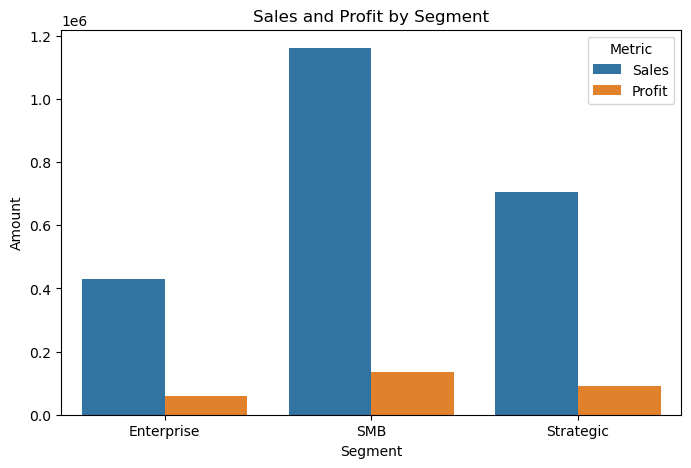

In [66]:
#Visualisasi Sales dan Profit by Segment
segment_melt = segment_perf.melt(
    id_vars='Segment',
    value_vars=['Sales', 'Profit'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(8,5))
sns.barplot(data=segment_melt, x='Segment', y='Amount', hue='Metric')
plt.title('Sales and Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Amount')
plt.show()

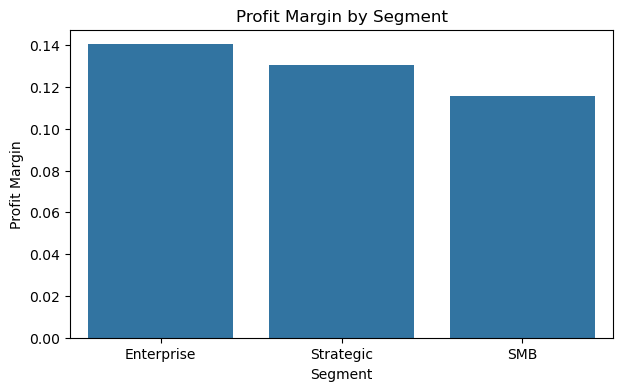

In [67]:
#Visualisasi Profit Margin by Segment
plt.figure(figsize=(7,4))
sns.barplot(
    data=segment_perf.sort_values('Profit Margin', ascending=False),
    x='Segment',
    y='Profit Margin'
)
plt.title('Profit Margin by Segment')
plt.xlabel('Segment')
plt.ylabel('Profit Margin')
plt.show()

Berdasarkan analisis segment, SMB menjadi segment dengan total sales dan profit tertinggi. Hal ini menunjukkan bahwa SMB merupakan kontributor utama terhadap revenue dan profit perusahaan.

Namun, jika dilihat dari profit margin, Enterprise memiliki margin tertinggi dibanding segment lainnya. Artinya, meskipun Enterprise memiliki total sales dan profit yang lebih rendah, segment ini lebih efisien dalam menghasilkan profit dari setiap sales yang diperoleh.

Dengan demikian, perusahaan perlu mempertahankan SMB sebagai sumber utama revenue, tetapi juga mempertimbangkan Enterprise sebagai segment potensial karena memiliki profit margin yang lebih tinggi.

Actionable Recommendation
Perusahaan dapat mempertahankan SMB sebagai segment utama untuk mendorong sales dan profit total. Namun, Enterprise juga perlu diprioritaskan dalam strategi sales karena memiliki profit margin paling tinggi. Strategi untuk SMB dapat difokuskan pada volume dan retention, sedangkan strategi untuk Enterprise dapat difokuskan pada high-value account dan upselling produk dengan margin tinggi.

In [74]:
#Insight 8 - Product by Sales
#Mengetahui produk SaaS mana yang paling besar kontribusinya terhadap sales/revenue
product_perf = df.groupby('Product').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

product_perf['Profit Margin'] = product_perf['Profit'] / product_perf['Sales']

product_perf.sort_values('Sales', ascending=False)

,Product,Sales,Profit,Quantity,Orders,Profit Margin
3,ContactMatcher,410378.2650,12496.2822,7215,1552,0.030451
5,FinanceHub,340935.4150,32136.4203,3756,886,0.094260
11,Site Analytics,330007.0540,44515.7306,3289,814,0.134893
7,Marketing Suite - Gold,223843.6080,21278.8264,3158,777,0.095061
1,Big Ol Database,189238.6310,3384.7569,440,112,0.017886
4,Data Smasher,167380.3180,41936.6357,2976,718,0.250547
0,Alchemy,149528.0300,55617.8249,234,68,0.371956
13,Support,125152.7440,32864.4698,5825,1333,0.262595
6,Marketing Suite,114879.9963,-3472.5560,868,224,-0.030228
8,OneView,107532.1610,18138.0054,1729,451,0.168675


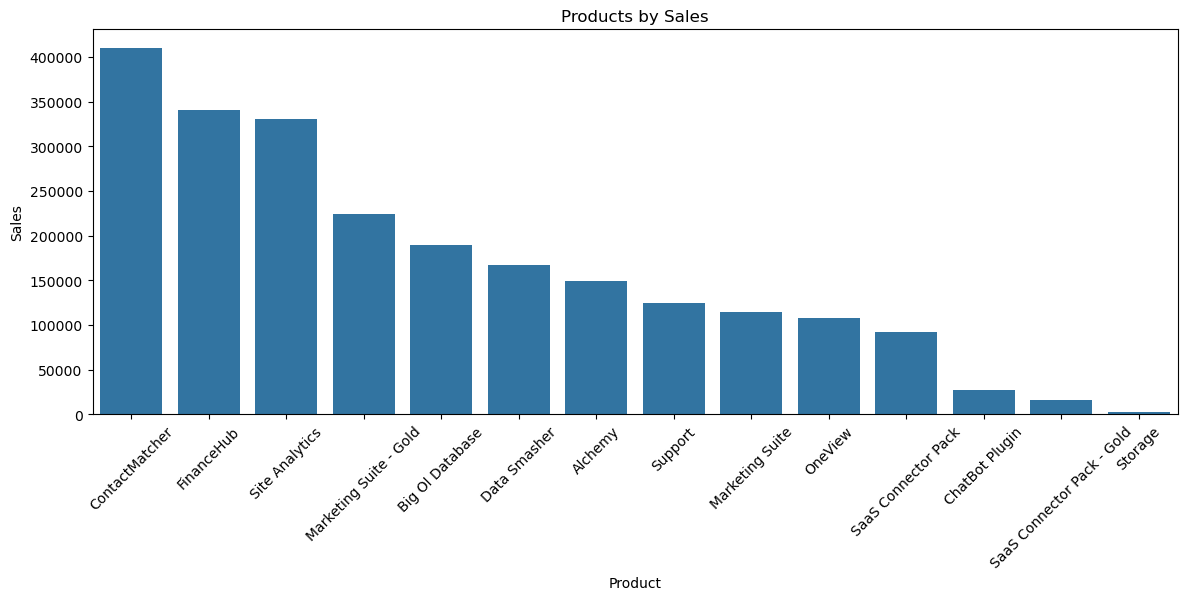

In [73]:
plt.figure(figsize=(14,5))
sns.barplot(data=product_perf.sort_values('Sales', ascending=False), x='Product', y='Sales')
plt.title('Products by Sales')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

Berdasarkan chart Products by Sales, ContactMatcher menjadi produk dengan total sales tertinggi, diikuti oleh FinanceHub dan Site Analytics. Hal ini menunjukkan bahwa ketiga produk tersebut merupakan main revenue driver bagi perusahaan.

Namun, analisis berdasarkan sales saja belum cukup untuk menilai performa produk secara keseluruhan. Produk dengan sales tinggi belum tentu menghasilkan profit yang tinggi. Oleh karena itu, analisis selanjutnya perlu melihat performa produk berdasarkan profit dan profit margin agar perusahaan dapat mengetahui produk mana yang benar-benar paling menguntungkan.

ContactMatcher menjadi produk dengan sales tertinggi, tetapi produk sales tertinggi masih perlu dievaluasi dari sisi profit dan profit margin untuk memastikan kontribusinya terhadap profitabilitas.

In [75]:
#Insight 9 - Product by Profit


product_perf = df.groupby('Product').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

product_perf['Profit Margin'] = product_perf['Profit'] / product_perf['Sales']

product_perf.sort_values('Profit', ascending=False)

,Product,Sales,Profit,Quantity,Orders,Profit Margin
0,Alchemy,149528.0300,55617.8249,234,68,0.371956
11,Site Analytics,330007.0540,44515.7306,3289,814,0.134893
4,Data Smasher,167380.3180,41936.6357,2976,718,0.250547
13,Support,125152.7440,32864.4698,5825,1333,0.262595
5,FinanceHub,340935.4150,32136.4203,3756,886,0.094260
7,Marketing Suite - Gold,223843.6080,21278.8264,3158,777,0.095061
8,OneView,107532.1610,18138.0054,1729,451,0.168675
9,SaaS Connector Pack,91705.1640,13059.1436,3563,877,0.142404
3,ContactMatcher,410378.2650,12496.2822,7215,1552,0.030451
10,SaaS Connector Pack - Gold,16476.4020,6964.1767,906,249,0.422676


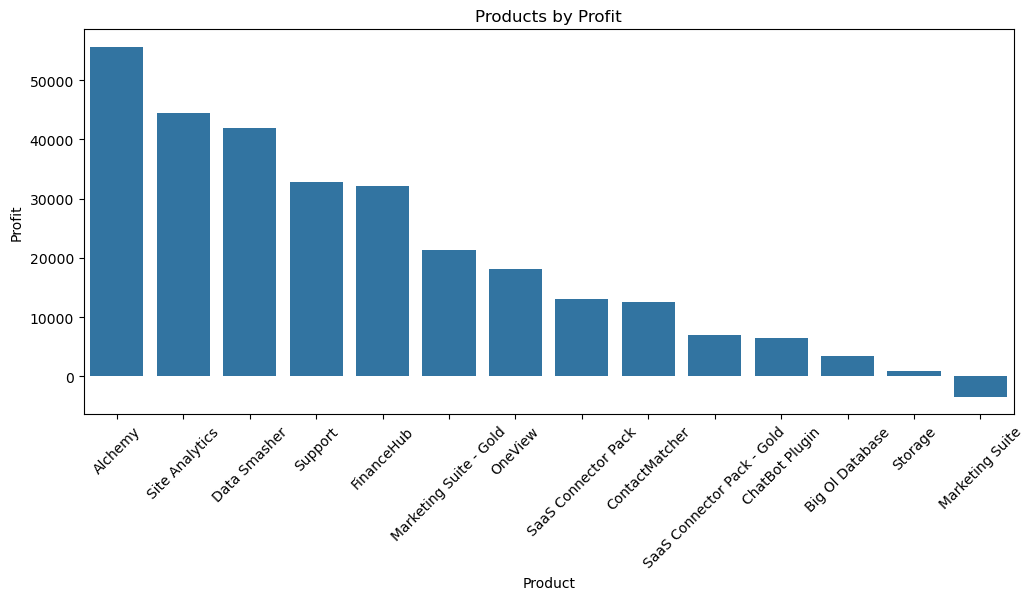

In [76]:
top_product_profit = product_perf.sort_values('Profit', ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(data=top_product_profit, x='Product', y='Profit')
plt.title('Products by Profit')
plt.xlabel('Product')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

Berdasarkan chart Products by Profit, Alchemy menjadi produk dengan profit tertinggi, diikuti oleh Site Analytics, Data Smasher, Support, dan FinanceHub. Hal ini menunjukkan bahwa produk-produk tersebut merupakan kontributor utama terhadap profit perusahaan.

Jika dibandingkan dengan analisis product by sales sebelumnya, ContactMatcher memiliki sales tertinggi tetapi tidak menjadi produk dengan profit tertinggi. Ini menunjukkan bahwa sales yang tinggi belum tentu menghasilkan profit yang optimal.

Selain itu, Marketing Suite memiliki profit negatif, sehingga produk ini perlu dievaluasi lebih lanjut dari sisi pricing, discount, atau cost structure.

Actionable Item: Perusahaan dapat memprioritaskan produk seperti Alchemy, Site Analytics, dan Data Smasher karena memberikan kontribusi profit yang tinggi. Untuk ContactMatcher, perusahaan perlu mengevaluasi profit margin-nya karena meskipun sales-nya tinggi, kontribusi profitnya tidak sebesar produk utama lainnya. Marketing Suite perlu dievaluasi lebih lanjut karena menghasilkan profit negatif.

In [77]:
#Insight 10 - High Sales but Low Profit Margin Product
#Untuk mengidentifikasi produk yang terlihat bagus dari sisi sales, tetapi kurang optimal dari sisi profitabilitas

sales_threshold = product_perf['Sales'].median()
margin_threshold = product_perf['Profit Margin'].median()

high_sales_low_margin = product_perf[
    (product_perf['Sales'] > sales_threshold) &
    (product_perf['Profit Margin'] < margin_threshold)
].sort_values('Sales', ascending=False)

high_sales_low_margin

,Product,Sales,Profit,Quantity,Orders,Profit Margin
3,ContactMatcher,410378.265,12496.2822,7215,1552,0.030451
5,FinanceHub,340935.415,32136.4203,3756,886,0.094260
11,Site Analytics,330007.054,44515.7306,3289,814,0.134893
7,Marketing Suite - Gold,223843.608,21278.8264,3158,777,0.095061
1,Big Ol Database,189238.631,3384.7569,440,112,0.017886


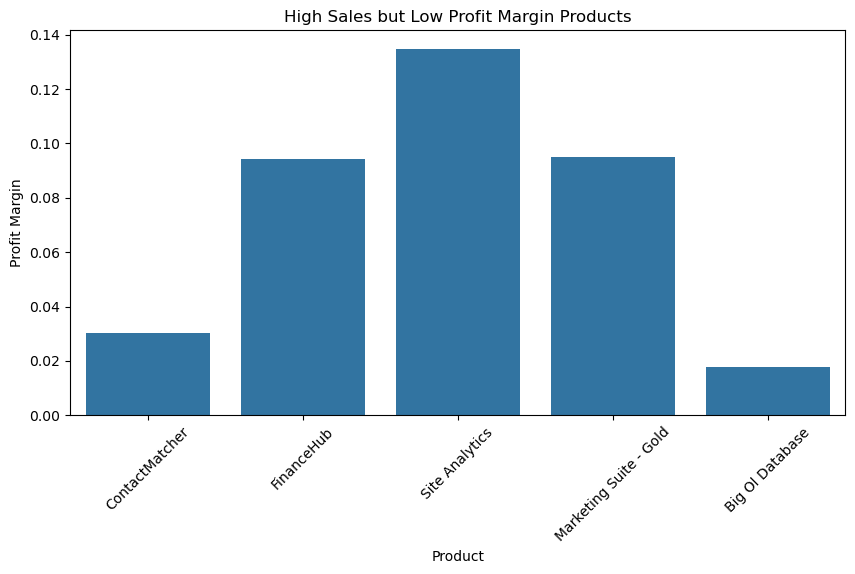

In [80]:
plt.figure(figsize=(10,5))
sns.barplot(data=high_sales_low_margin, x='Product', y='Profit Margin')
plt.title('High Sales but Low Profit Margin Products')
plt.xlabel('Product')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)
plt.show()

In [81]:
#Export Data for Tableau
df.to_csv("SaaS_Sales_Cleaned.csv", index=False)

In [82]:
import os
os.getcwd()

'C:\\Users\\Erika\\Capstone 2 Final'